# Inspect JEPA HDF5 shapes

This notebook summarizes the structure of an extracted JEPA embedding HDF5 produced by `app/vjepa_droid/extract_jepa_vectors.py`.

It is designed to be safe on very large files: it **reads dataset metadata (shapes/dtypes/chunks/compression)** without loading whole arrays, and optionally scans only a sample of videos.

**Default file** (edit as needed): `/tmp2/hubertchang/p-jepa/data/droid/jepa_rep/jepa_vectors.h5`


In [1]:
import os
import random
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
except Exception:
    pd = None

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

# ---- Config ----
H5_PATH = os.environ.get("JEPA_H5_PATH", "/tmp2/hubertchang/p-jepa/data/droid/jepa_rep/jepa_vectors_test_part0000.h5")

# Scan only a subset by default (faster on huge files)
SCAN_MODE = "sample"  # "sample" or "all"
N_SAMPLE = 2000
RANDOM_SEED = 0

# Plot settings
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

H5_PATH

'/tmp2/hubertchang/p-jepa/data/droid/jepa_rep/jepa_vectors_test_part0000.h5'

In [3]:
h5_path = Path(H5_PATH)
if not h5_path.exists():
    raise FileNotFoundError(f"H5 not found: {h5_path}")

size_gb = h5_path.stat().st_size / (1024**3)
print(f"H5: {h5_path} ({size_gb:.2f} GiB)")

f = h5py.File(h5_path, "r")
keys = list(f.keys())
print(f"num video groups: {len(keys):,}")
print("first 5 keys:")
for k in keys[:5]:
    print(" -", k)

keys[:3]

H5: /tmp2/hubertchang/p-jepa/data/droid/jepa_rep/jepa_vectors_test_part0000.h5 (0.05 GiB)
num video groups: 5
first 5 keys:
 - chunk-000__observation.images.exterior_image_1_left__episode_000000
 - chunk-000__observation.images.exterior_image_1_left__episode_000001
 - chunk-000__observation.images.exterior_image_1_left__episode_000002
 - chunk-000__observation.images.exterior_image_1_left__episode_000003
 - chunk-000__observation.images.exterior_image_1_left__episode_000004


['chunk-000__observation.images.exterior_image_1_left__episode_000000',
 'chunk-000__observation.images.exterior_image_1_left__episode_000001',
 'chunk-000__observation.images.exterior_image_1_left__episode_000002']

In [4]:
def _maybe_storage_size_bytes(dset: h5py.Dataset):
    try:
        return int(dset.id.get_storage_size())
    except Exception:
        return None


def dataset_info(dset: h5py.Dataset) -> dict:
    shape = tuple(int(x) for x in dset.shape)
    dtype = str(dset.dtype)
    chunks = dset.chunks
    compression = dset.compression
    compression_opts = dset.compression_opts
    logical_nbytes = int(np.prod(shape)) * dset.dtype.itemsize if len(shape) > 0 else dset.dtype.itemsize
    storage_bytes = _maybe_storage_size_bytes(dset)
    return {
        "shape": shape,
        "dtype": dtype,
        "chunks": chunks,
        "compression": compression,
        "compression_opts": compression_opts,
        "logical_nbytes": logical_nbytes,
        "storage_bytes": storage_bytes,
    }


def group_summary(g: h5py.Group) -> dict:
    out = {}
    if "embeddings" in g:
        out["embeddings"] = dataset_info(g["embeddings"])
    else:
        out["embeddings"] = None
    if "frame_indices" in g:
        out["frame_indices"] = dataset_info(g["frame_indices"])
    else:
        out["frame_indices"] = None
    return out


def select_keys(keys):
    if SCAN_MODE == "all":
        return keys
    rng = random.Random(RANDOM_SEED)
    if len(keys) <= N_SAMPLE:
        return keys
    return rng.sample(keys, k=N_SAMPLE)


sel_keys = select_keys(keys)
print(f"scan mode={SCAN_MODE}, scanning {len(sel_keys):,} / {len(keys):,} keys")
sel_keys[:3]

scan mode=sample, scanning 5 / 5 keys


['chunk-000__observation.images.exterior_image_1_left__episode_000000',
 'chunk-000__observation.images.exterior_image_1_left__episode_000001',
 'chunk-000__observation.images.exterior_image_1_left__episode_000002']

In [5]:
rows = []
it = sel_keys
if tqdm is not None:
    it = tqdm(sel_keys, desc="Scanning groups")

missing = {"embeddings": 0, "frame_indices": 0}
for k in it:
    g = f[k]
    summ = group_summary(g)
    emb = summ["embeddings"]
    fi = summ["frame_indices"]
    if emb is None:
        missing["embeddings"] += 1
    if fi is None:
        missing["frame_indices"] += 1

    # Expected shapes from extractor: embeddings [T, N_tokens, D], frame_indices [T]
    emb_shape = emb["shape"] if emb is not None else None
    fi_shape = fi["shape"] if fi is not None else None
    T = int(emb_shape[0]) if emb_shape is not None and len(emb_shape) >= 1 else None
    N_tokens = int(emb_shape[1]) if emb_shape is not None and len(emb_shape) >= 2 else None
    D = int(emb_shape[2]) if emb_shape is not None and len(emb_shape) >= 3 else None

    rows.append({
        "key": k,
        "T": T,
        "N_tokens": N_tokens,
        "D": D,
        "emb_dtype": emb["dtype"] if emb is not None else None,
        "emb_compression": emb["compression"] if emb is not None else None,
        "emb_chunks": emb["chunks"] if emb is not None else None,
        "emb_logical_nbytes": emb["logical_nbytes"] if emb is not None else None,
        "emb_storage_bytes": emb["storage_bytes"] if emb is not None else None,
        "fi_shape": fi_shape,
        "fi_dtype": fi["dtype"] if fi is not None else None,
    })

print("missing datasets:", missing)
len(rows)

Scanning groups:   0%|          | 0/5 [00:00<?, ?it/s]

missing datasets: {'embeddings': 0, 'frame_indices': 0}


5

T summary: {'count': 5, 'min': 5.0, 'p50': 7.0, 'p90': 8.6, 'p99': 8.96, 'max': 9.0, 'mean': 7.2}
N_tokens unique (sample): [256]
D unique (sample): [1408]


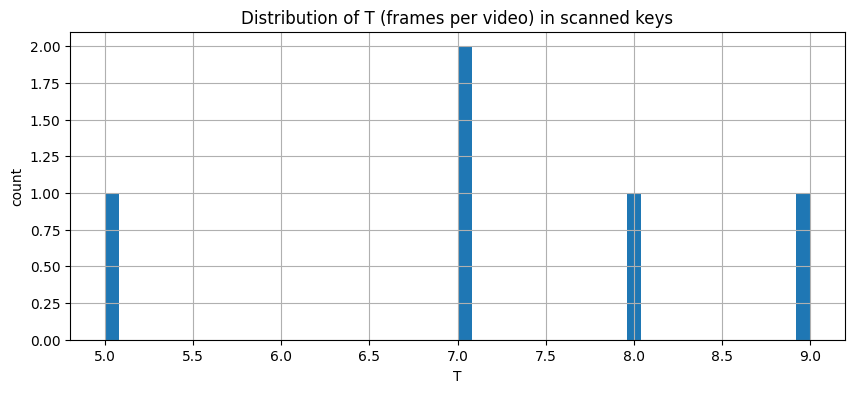

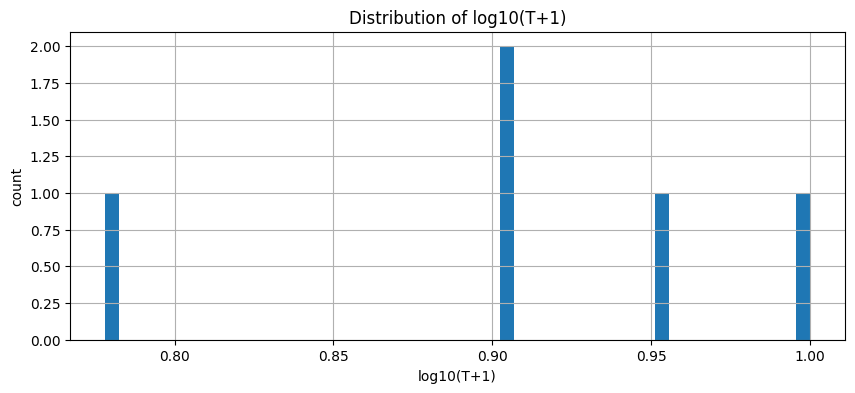

In [6]:
def summarize_numeric(x: np.ndarray) -> dict:
    x = x[np.isfinite(x)]
    if x.size == 0:
        return {}
    return {
        "count": int(x.size),
        "min": float(np.min(x)),
        "p50": float(np.percentile(x, 50)),
        "p90": float(np.percentile(x, 90)),
        "p99": float(np.percentile(x, 99)),
        "max": float(np.max(x)),
        "mean": float(np.mean(x)),
    }


T_arr = np.array([r["T"] if r["T"] is not None else np.nan for r in rows], dtype=np.float64)
Nt_arr = np.array([r["N_tokens"] if r["N_tokens"] is not None else np.nan for r in rows], dtype=np.float64)
D_arr = np.array([r["D"] if r["D"] is not None else np.nan for r in rows], dtype=np.float64)

print("T summary:", summarize_numeric(T_arr))
print("N_tokens unique (sample):", sorted(set(int(x) for x in Nt_arr[np.isfinite(Nt_arr)]))[:20])
print("D unique (sample):", sorted(set(int(x) for x in D_arr[np.isfinite(D_arr)]))[:20])

valid_T = T_arr[np.isfinite(T_arr)]
plt.hist(valid_T, bins=50)
plt.title("Distribution of T (frames per video) in scanned keys")
plt.xlabel("T")
plt.ylabel("count")
plt.show()

plt.hist(np.log10(valid_T + 1), bins=50)
plt.title("Distribution of log10(T+1)")
plt.xlabel("log10(T+1)")
plt.ylabel("count")
plt.show()

In [7]:
# Largest T in the scanned set
rows_sorted = sorted([r for r in rows if r["T"] is not None], key=lambda r: r["T"], reverse=True)
top = rows_sorted[:20]
if pd is not None:
    display(pd.DataFrame(top)[["key", "T", "N_tokens", "D", "emb_dtype", "emb_compression", "fi_shape"]])
else:
    for r in top:
        print(r["T"], r["key"], r["N_tokens"], r["D"], r["fi_shape"])

,key,T,N_tokens,D,emb_dtype,emb_compression,fi_shape
0,chunk-000__observation.images.exterior_image_2...,17,256,1408,float32,gzip,"(17,)"
1,chunk-000__observation.images.exterior_image_1...,15,256,1408,float32,gzip,"(15,)"
2,chunk-001__observation.images.exterior_image_1...,14,256,1408,float32,gzip,"(14,)"
3,chunk-000__observation.images.exterior_image_1...,14,256,1408,float32,gzip,"(14,)"
4,chunk-001__observation.images.exterior_image_1...,14,256,1408,float32,gzip,"(14,)"
5,chunk-000__observation.images.exterior_image_2...,14,256,1408,float32,gzip,"(14,)"
6,chunk-000__observation.images.exterior_image_2...,13,256,1408,float32,gzip,"(13,)"
7,chunk-000__observation.images.exterior_image_1...,13,256,1408,float32,gzip,"(13,)"
8,chunk-001__observation.images.exterior_image_1...,13,256,1408,float32,gzip,"(13,)"
9,chunk-000__observation.images.exterior_image_2...,13,256,1408,float32,gzip,"(13,)"


In [22]:
# Inspect a single key in more detail (metadata only)
k = rows_sorted[0]["key"] if rows_sorted else keys[0]
g = f[k]
print("key:", k)
print("datasets:", list(g.keys()))
if "embeddings" in g:
    print("embeddings:", dataset_info(g["embeddings"]))
if "frame_indices" in g:
    print("frame_indices:", dataset_info(g["frame_indices"]))

# Optional: read a tiny slice to sanity check without loading everything
if "embeddings" in g:
    emb = g["embeddings"]
    T = emb.shape[0]
    sl = emb[: min(2, T)]
    print("tiny embeddings slice shape:", sl.shape, "dtype:", sl.dtype)
if "frame_indices" in g:
    fi = g["frame_indices"]
    sl_fi = fi[: min(10, fi.shape[0])]
    print("tiny frame_indices:", sl_fi)

key: chunk-000__observation.images.exterior_image_1_left__episode_000003
datasets: ['embeddings', 'frame_indices']
embeddings: {'shape': (8, 256, 1408), 'dtype': 'float32', 'chunks': (1, 32, 352), 'compression': 'gzip', 'compression_opts': 4, 'logical_nbytes': 11534336, 'storage_bytes': 10781389}
frame_indices: {'shape': (8,), 'dtype': 'int64', 'chunks': (8,), 'compression': 'gzip', 'compression_opts': 4, 'logical_nbytes': 64, 'storage_bytes': 32}
tiny embeddings slice shape: (2, 256, 1408) dtype: float32
tiny frame_indices: [ 61 119 200 262 321 471 543 666]


## Cleanup

If you opened a file handle `f`, you can close it when done:

```python
f.close()
```


In [5]:
f.close()